In [173]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

### I. Data preparation

In [174]:
df = pd.read_csv("src/boston.csv")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     505 non-null    float64
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      504 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  MEDV     505 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB


In [175]:
df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
1,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
2,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
3,0.03237,NaN,2.18,0.0,0.458,6.998,NaN,6.0622,3,NaN,18.7,NaN,2.94,NaN
4,NaN,0.0,2.18,NaN,NaN,NaN,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,NaN,NaN,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,NaN,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


In [176]:
def plot_histogram(
    x_data: pd.Series,    # if it not a Series the code fail
    num_bins: int = 50,
):
    """
    Calculates and plots a histogram using Matplotlib.
    """
    # Create the histogram
    # edgecolor adds a border to the bars so they don't bleed together
    plt.hist(x_data, bins=num_bins, edgecolor='black', alpha=0.7)
    
    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.title(f'Distribution of "{x_data.name}" values')
    
    # Render the plot
    plt.show()

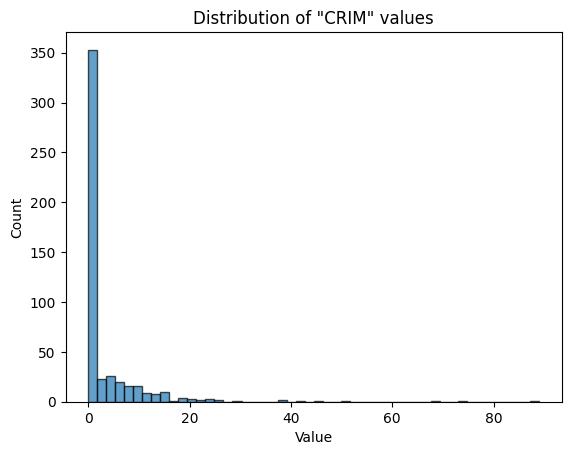

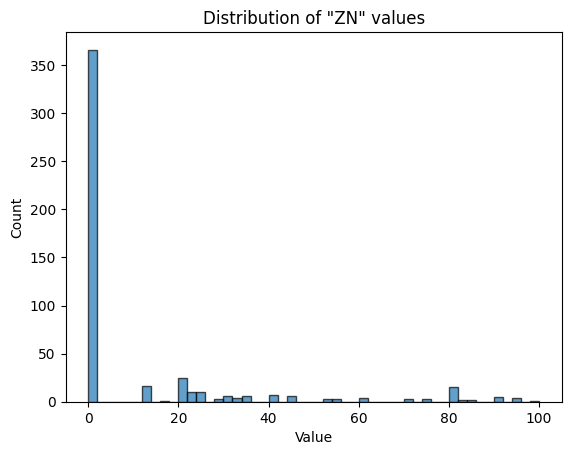

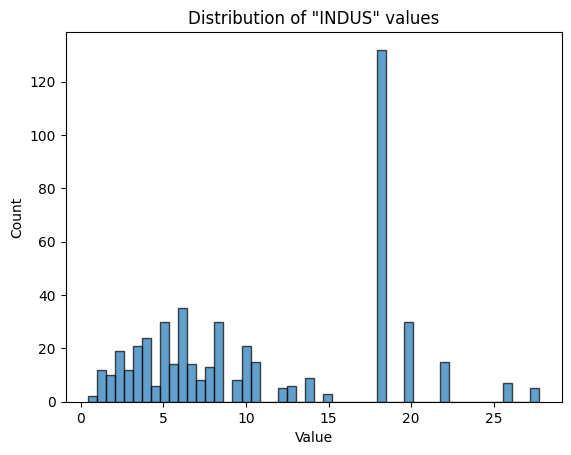

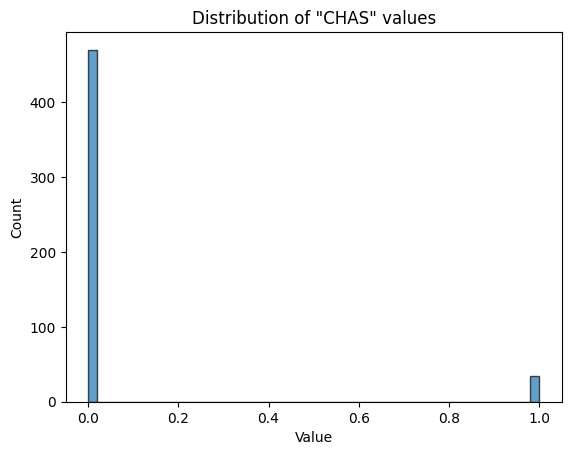

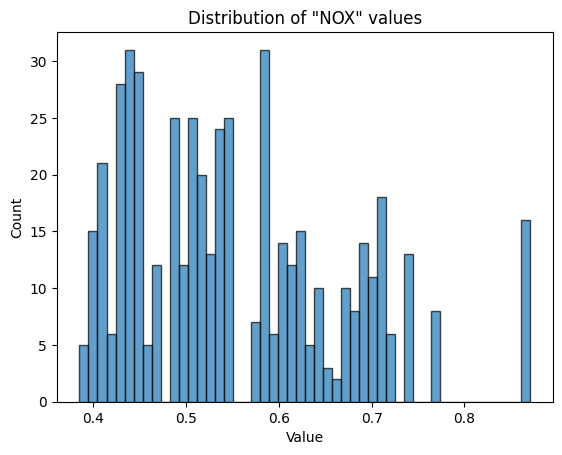

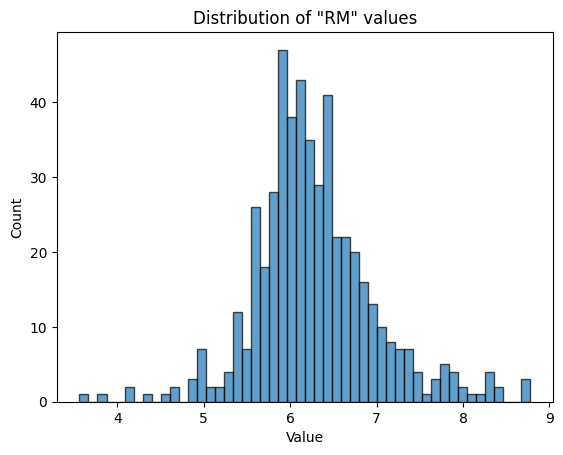

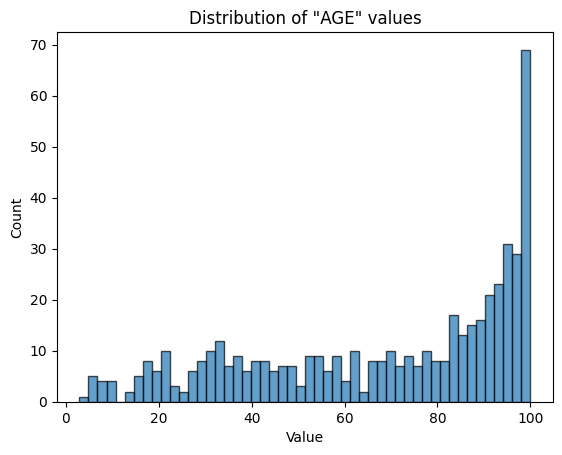

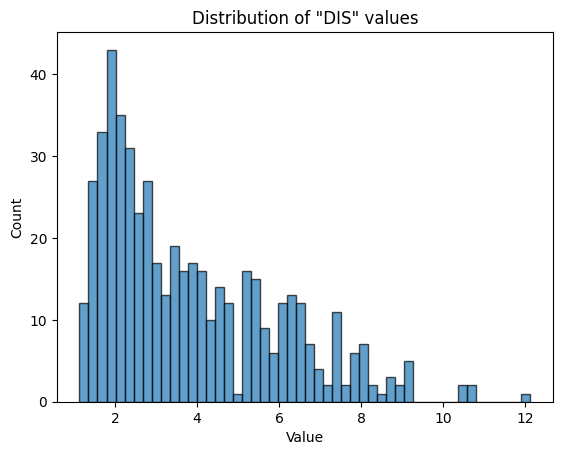

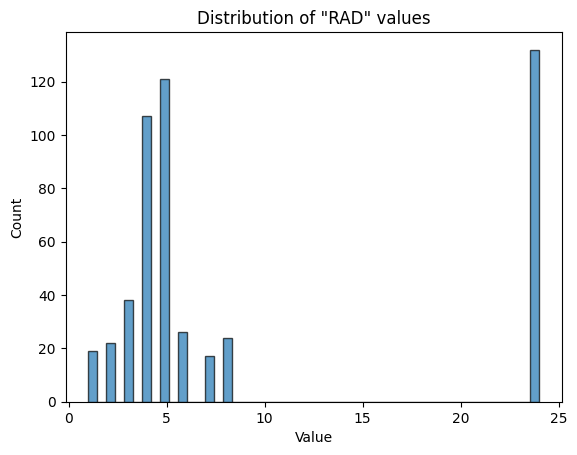

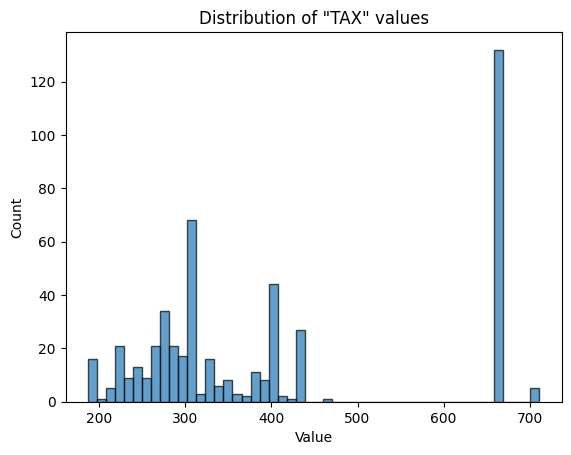

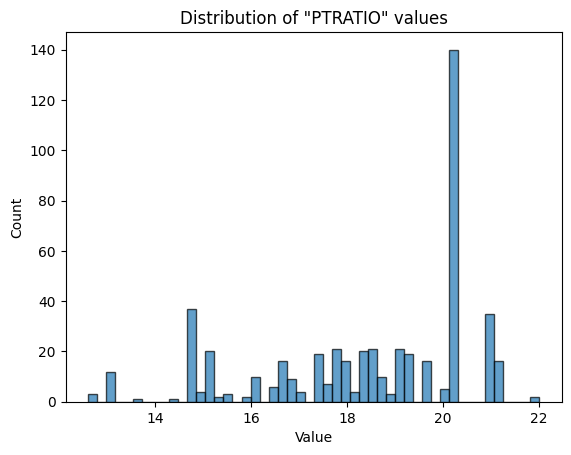

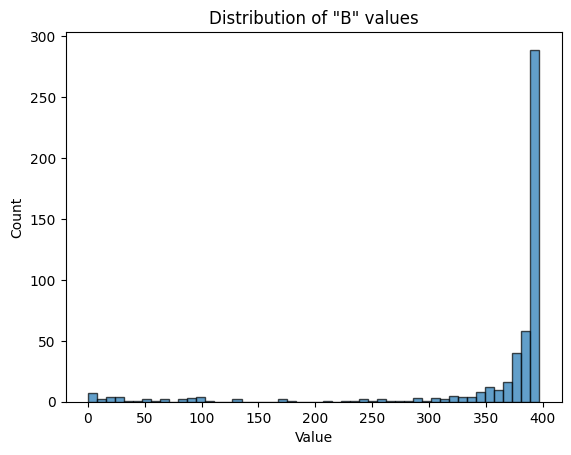

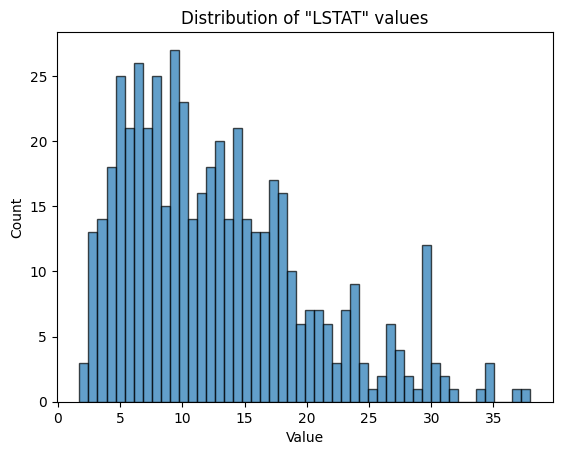

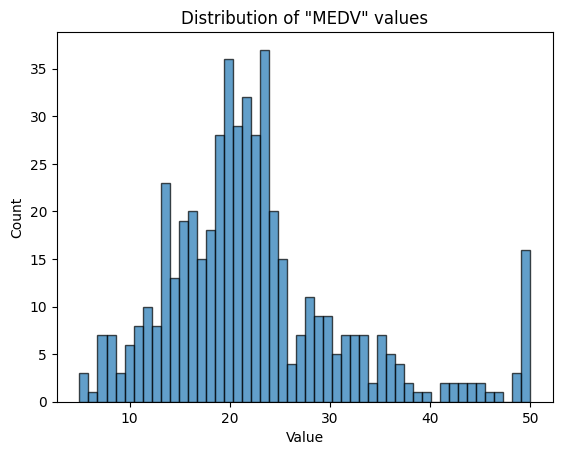

In [177]:
for col in df.columns:
    plot_histogram(df[col])

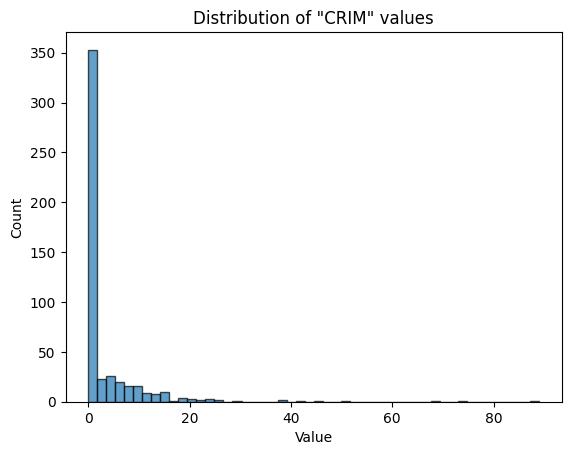

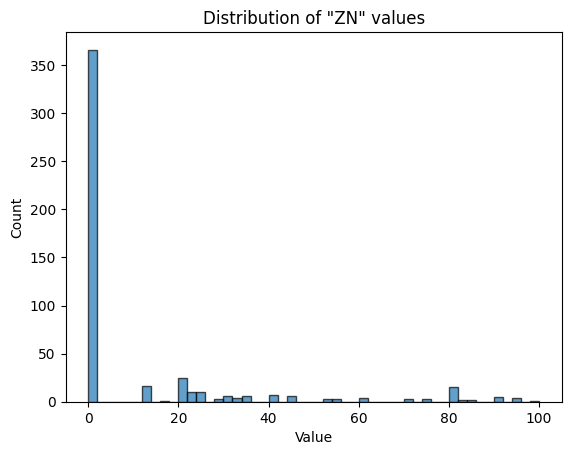

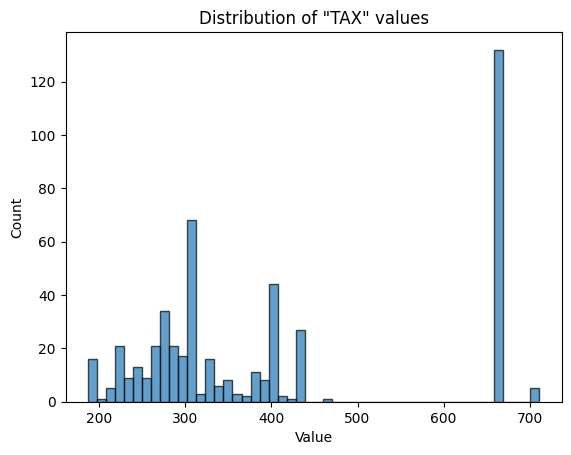

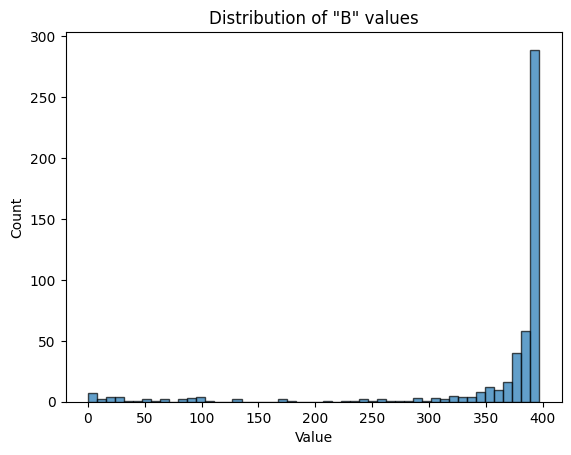

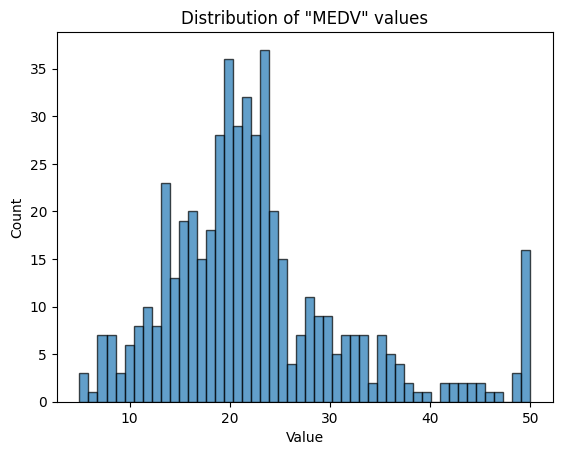

In [178]:
top_skewed_cols = df.columns[[0, 1, 9, 11, 13]]

for col in top_skewed_cols:
    plot_histogram(df[col])

### II. Actual task.
#### 1. Perform Standardization (z-Score Scaling)
$$
X_{std} = \frac{X - \mu}{\sigma}
$$


In [179]:
z_score_df = pd.DataFrame()
for col_name in top_skewed_cols:
    z_score_df[col_name] = (df[col_name] - np.mean(df[col_name])) / np.std(df[col_name])

z_score_df.head(10)

,CRIM,ZN,TAX,B,MEDV
0,-0.395935,0.042984,-0.584982,0.327747,-0.649104
1,-0.395935,0.042984,-0.584982,0.327747,-0.649104
2,-0.395935,0.042984,-0.584982,0.327747,-0.649104
3,-0.416731,NaN,NaN,NaN,NaN
4,NaN,-0.493782,-1.114601,0.440299,1.497994
5,-0.417024,-0.493782,NaN,0.409832,0.680571
6,-0.410230,0.042984,-0.584982,0.426051,0.048430
7,-0.403689,0.042984,-0.584982,0.440299,0.506187
8,-0.395935,0.042984,-0.584982,0.327747,-0.649104
9,-0.400725,0.042984,-0.584982,0.328623,-0.387529


In [180]:
z_score_df.describe()

,CRIM,ZN,TAX,B,MEDV
count,5.050000e+02,5.050000e+02,5.040000e+02,5.050000e+02,5.050000e+02
mean,-8.442092e-17,-8.793846e-19,-1.691768e-16,1.407015e-17,1.407015e-17
std,1.000992e+00,1.000992e+00,1.000994e+00,1.000992e+00,1.000992e+00
min,-4.194410e-01,-4.937825e-01,-1.322878e+00,-3.905940e+00,-1.902486e+00
25%,-4.108354e-01,-4.937825e-01,-7.635056e-01,2.059888e-01,-6.273061e-01
50%,-3.911977e-01,-4.937825e-01,-4.719176e-01,3.785977e-01,-1.477512e-01
75%,7.140379e-03,4.298382e-02,1.527542e+00,4.327366e-01,2.773087e-01
max,9.923997e+00,3.800348e+00,1.795327e+00,4.402986e-01,3.002052e+00


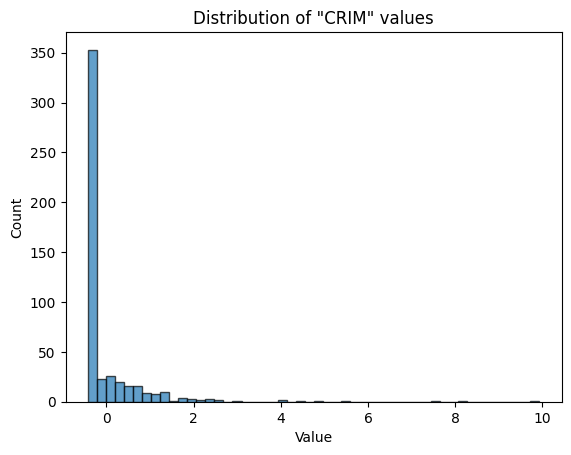

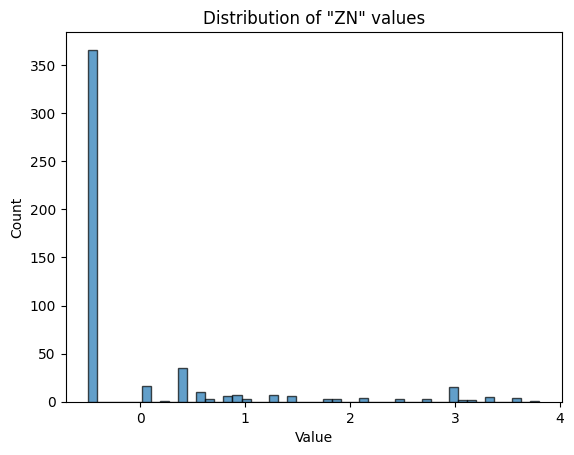

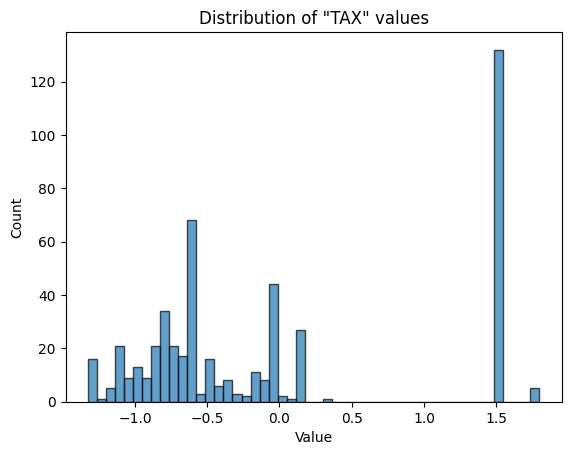

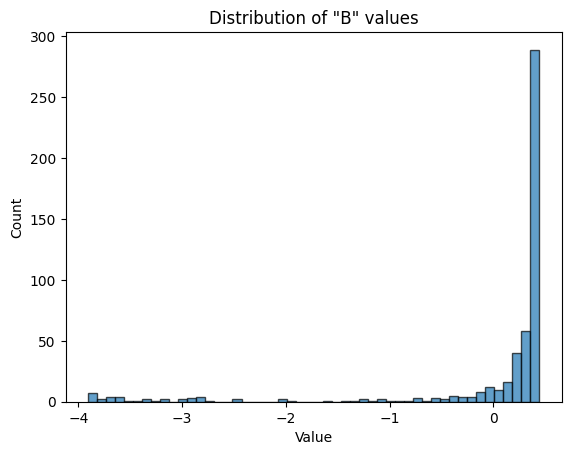

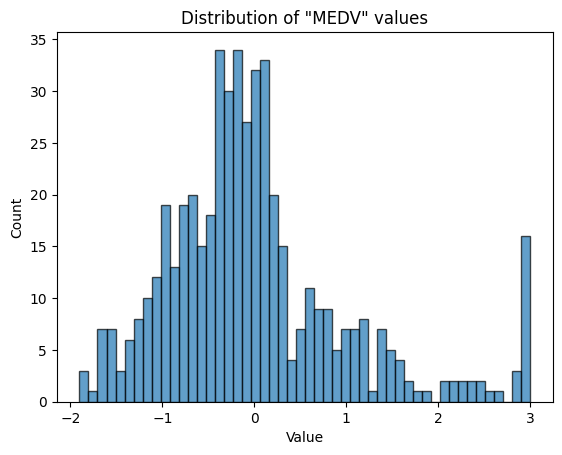

In [181]:
for col in z_score_df:
    plot_histogram(z_score_df[col])

#### 2. Min-Max Normalization
$$
X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$


In [182]:
mm_sc_df = pd.DataFrame()
for col_name in top_skewed_cols:
    mm_sc_df[col_name] = (df[col_name] - np.min(df[col_name])) / (np.max(df[col_name]) - np.min(df[col_name])) 
    
mm_sc_df.head(10)


,CRIM,ZN,TAX,B,MEDV
0,0.002273,0.125,0.236641,0.974104,0.255556
1,0.002273,0.125,0.236641,0.974104,0.255556
2,0.002273,0.125,0.236641,0.974104,0.255556
3,0.000262,NaN,NaN,NaN,NaN
4,NaN,0.000,0.066794,1.000000,0.693333
5,0.000234,0.000,NaN,0.992990,0.526667
6,0.000891,0.125,0.236641,0.996722,0.397778
7,0.001523,0.125,0.236641,1.000000,0.491111
8,0.002273,0.125,0.236641,0.974104,0.255556
9,0.001809,0.125,0.236641,0.974305,0.308889


In [183]:
mm_sc_df.describe()

,CRIM,ZN,TAX,B,MEDV
count,505.000000,505.000000,504.000000,505.000000,505.000000
mean,0.040551,0.114990,0.424243,0.898694,0.387903
std,0.096776,0.233107,0.321016,0.230312,0.204095
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000832,0.000000,0.179389,0.946089,0.260000
50%,0.002731,0.000000,0.272901,0.985804,0.357778
75%,0.041242,0.125000,0.914122,0.998260,0.444444
max,1.000000,1.000000,1.000000,1.000000,1.000000


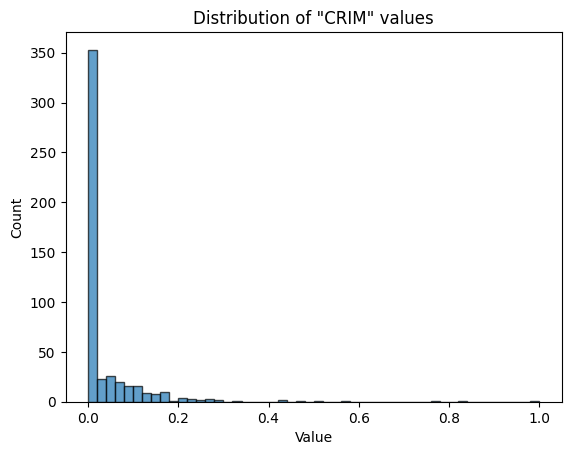

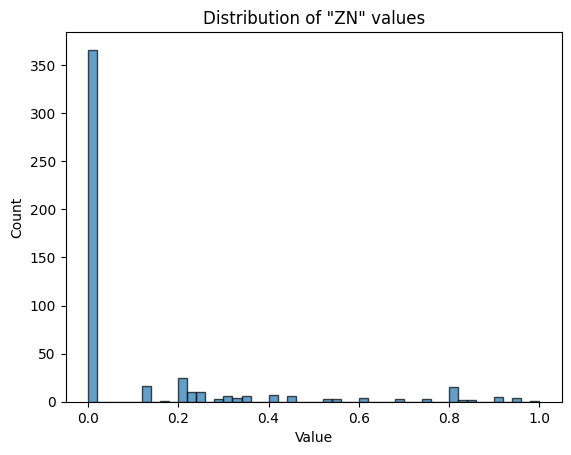

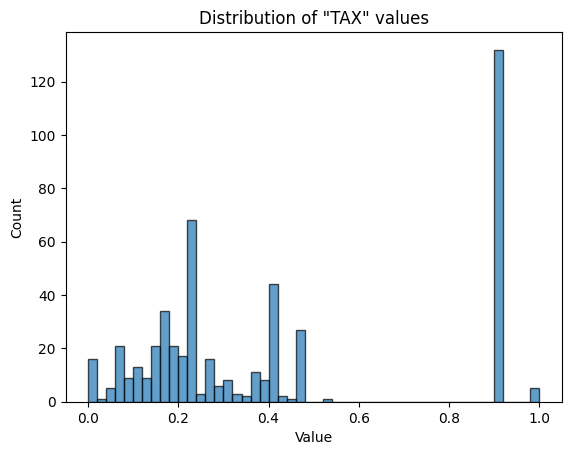

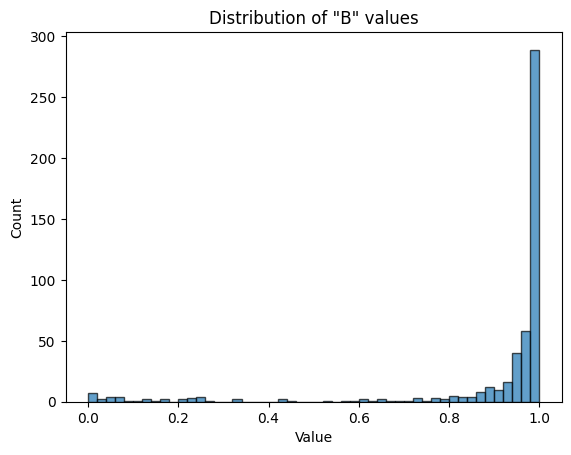

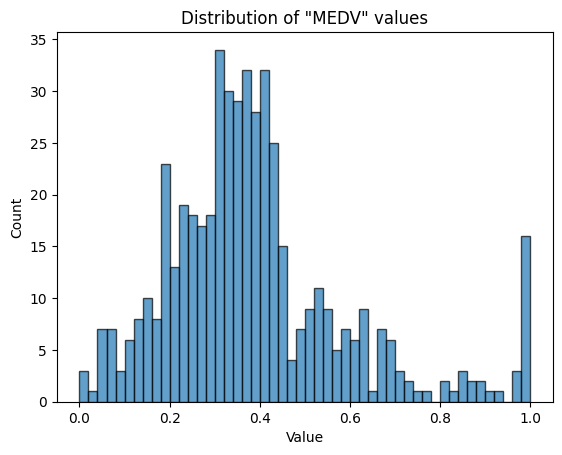

In [184]:
for col in mm_sc_df:
    plot_histogram(mm_sc_df[col])

#### 3. Robust Scaling
$$
X_{robust} = \frac{X - Q_2}{Q_3 - Q_1}
$$
where $Q_2$ - is the median, $Q_1$ - is 25th percentile, and $Q_3$ - is 75th percentile

In [185]:
robust_sc_df = pd.DataFrame()
for col_name in top_skewed_cols:
    iqr = df[col_name].quantile(0.75) - df[col_name].quantile(0.25)
    if iqr == 0:
        continue
    robust_sc_df[col_name] = (df[col_name] - df[col_name].median()) / iqr
    
robust_sc_df.head(10)


,CRIM,ZN,TAX,B,MEDV
0,-0.011335,1.0,-0.049351,-0.224263,-0.554217
1,-0.011335,1.0,-0.049351,-0.224263,-0.554217
2,-0.011335,1.0,-0.049351,-0.224263,-0.554217
3,-0.061088,NaN,NaN,NaN,NaN
4,NaN,0.0,-0.280519,0.272112,1.819277
5,-0.061789,0.0,NaN,0.137748,0.915663
6,-0.045534,1.0,-0.049351,0.209280,0.216867
7,-0.029885,1.0,-0.049351,0.272112,0.722892
8,-0.011335,1.0,-0.049351,-0.224263,-0.554217
9,-0.022795,1.0,-0.049351,-0.220396,-0.265060


In [186]:
robust_sc_df.describe()

,CRIM,ZN,TAX,B,MEDV
count,505.000000,505.000000,504.000000,505.000000,505.000000
mean,0.935934,0.919921,0.205983,-1.669686,0.163331
std,2.394856,1.864855,0.436915,4.414558,1.106539
min,-0.067572,0.000000,-0.371429,-18.895602,-1.939759
25%,-0.046983,0.000000,-0.127273,-0.761237,-0.530120
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.953017,1.000000,0.872727,0.238763,0.469880
max,24.678930,8.000000,0.989610,0.272112,3.481928


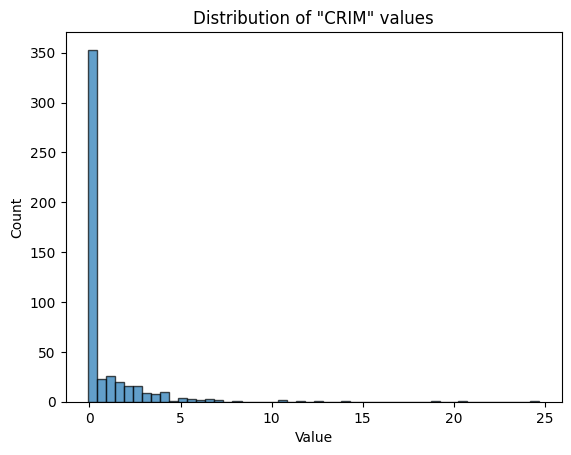

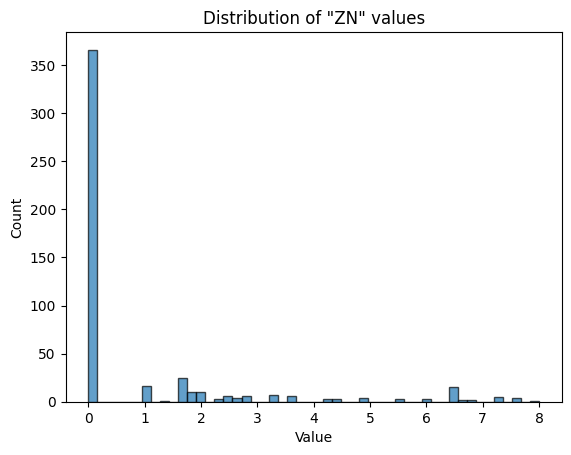

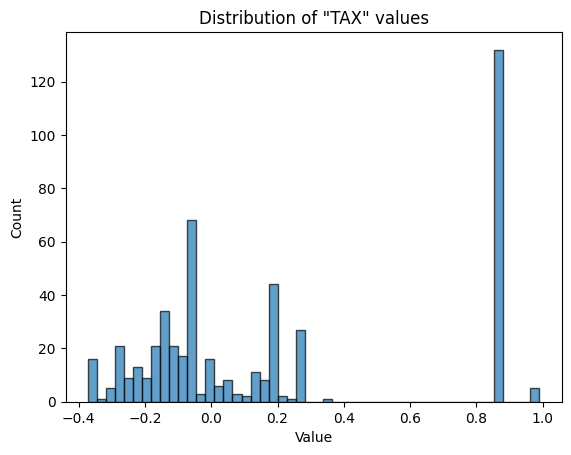

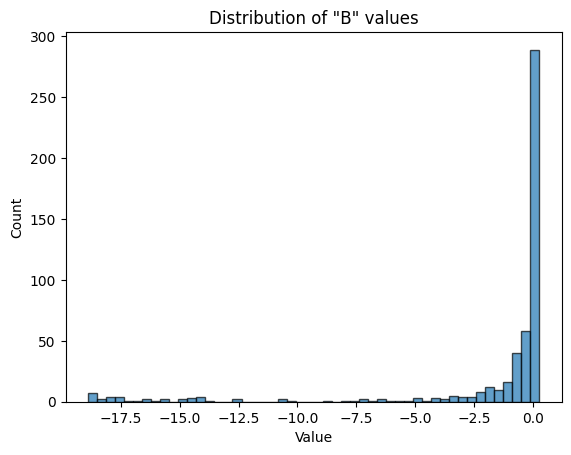

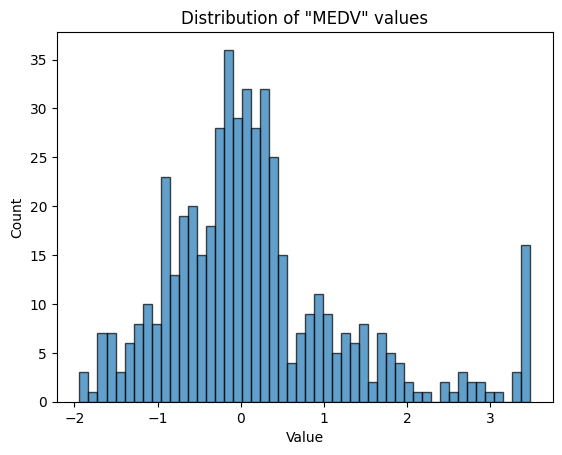

In [187]:
for col in robust_sc_df:
    plot_histogram(robust_sc_df[col])

#### 4. Max Absolute scaling
$$
X_{max\_abs} = \frac{X}{|X|_{max}}
$$

In [188]:
max_abs_sc_df = pd.DataFrame()
for col_name in top_skewed_cols:
    max_abs_sc_df[col_name] = df[col_name] / abs(np.max(df[col_name]))
    
max_abs_sc_df.head(10)


,CRIM,ZN,TAX,B,MEDV
0,0.002374,0.125,0.437412,0.974124,0.330
1,0.002374,0.125,0.437412,0.974124,0.330
2,0.002374,0.125,0.437412,0.974124,0.330
3,0.000364,NaN,NaN,NaN,NaN
4,NaN,0.000,0.312236,1.000000,0.724
5,0.000335,0.000,NaN,0.992996,0.574
6,0.000992,0.125,0.437412,0.996725,0.458
7,0.001625,0.125,0.437412,1.000000,0.542
8,0.002374,0.125,0.437412,0.974124,0.330
9,0.001911,0.125,0.437412,0.974326,0.378


In [189]:
max_abs_sc_df.describe()

,CRIM,ZN,TAX,B,MEDV
count,505.000000,505.000000,504.000000,505.000000,505.000000
mean,0.040649,0.114990,0.575673,0.898776,0.449113
std,0.096766,0.233107,0.236586,0.230126,0.183685
min,0.000102,0.000000,0.263010,0.000806,0.100000
25%,0.000934,0.000000,0.395218,0.946133,0.334000
50%,0.002832,0.000000,0.464135,0.985815,0.422000
75%,0.041339,0.125000,0.936709,0.998262,0.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000


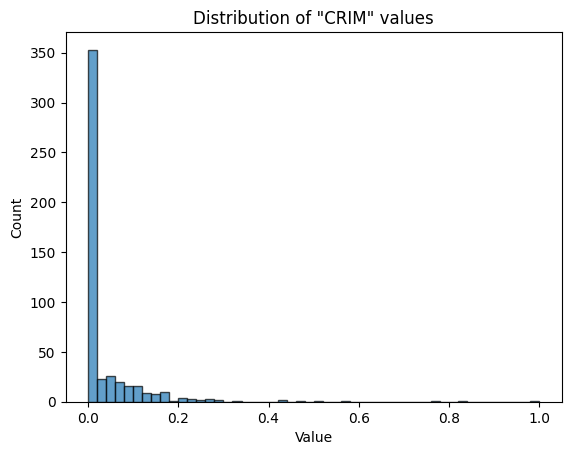

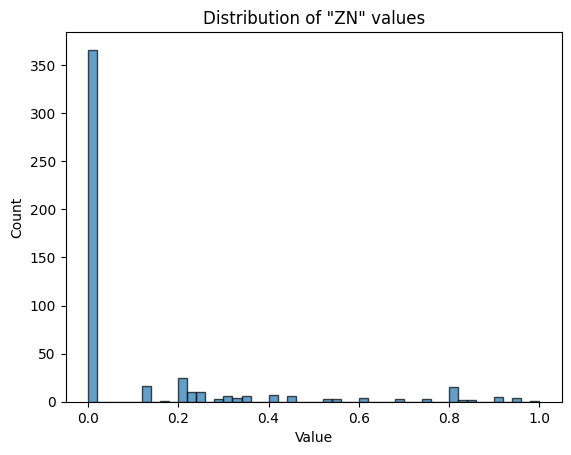

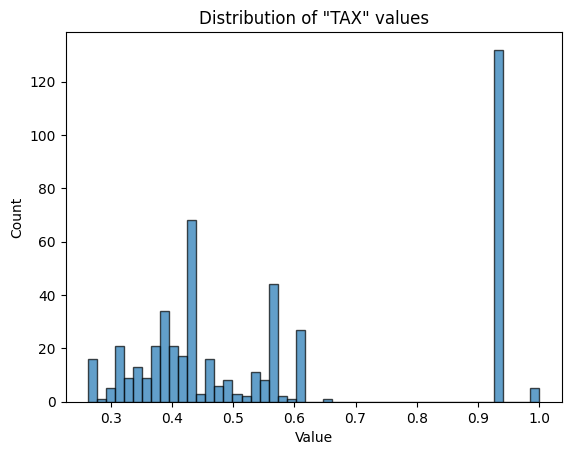

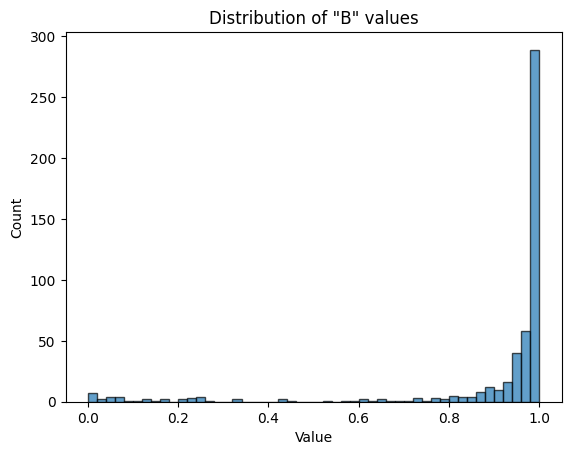

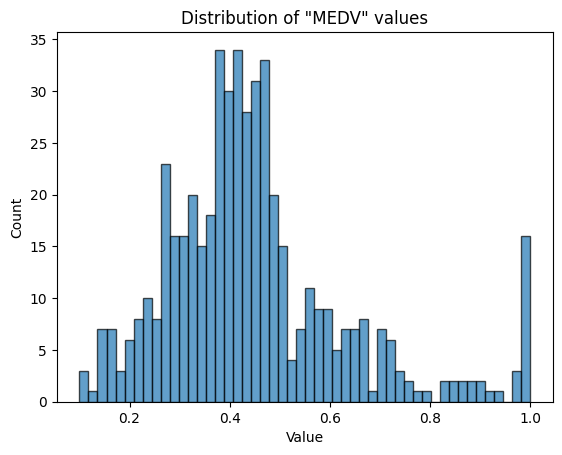

In [190]:
for col in max_abs_sc_df:
    plot_histogram(max_abs_sc_df[col])

#### 5. Mean Normalization
$$
X_{mean\_norm} = \frac{X - \mu}{X_{max} - X_{min}}
$$

In [191]:
mean_norm_df = pd.DataFrame()
for col_name in top_skewed_cols:
    mean_norm_df[col_name] = (df[col_name] - np.mean(df[col_name])) / (np.max(df[col_name]) - np.min(df[col_name]))
    
mean_norm_df.head(10)


,CRIM,ZN,TAX,B,MEDV
0,-0.038279,0.01001,-0.187602,0.075409,-0.132348
1,-0.038279,0.01001,-0.187602,0.075409,-0.132348
2,-0.038279,0.01001,-0.187602,0.075409,-0.132348
3,-0.040289,NaN,NaN,NaN,NaN
4,NaN,-0.11499,-0.357450,0.101306,0.305430
5,-0.040318,-0.11499,NaN,0.094296,0.138763
6,-0.039661,0.01001,-0.187602,0.098028,0.009875
7,-0.039028,0.01001,-0.187602,0.101306,0.103208
8,-0.038279,0.01001,-0.187602,0.075409,-0.132348
9,-0.038742,0.01001,-0.187602,0.075611,-0.079014


In [192]:
mean_norm_df.describe()

,CRIM,ZN,TAX,B,MEDV
count,5.050000e+02,5.050000e+02,5.040000e+02,5.050000e+02,5.050000e+02
mean,-1.407015e-17,-1.055261e-17,-2.819614e-17,-7.035077e-18,-3.517538e-18
std,9.677552e-02,2.331069e-01,3.210159e-01,2.303122e-01,2.040950e-01
min,-4.055141e-02,-1.149901e-01,-4.242435e-01,-8.986943e-01,-3.879032e-01
25%,-3.971942e-02,-1.149901e-01,-2.448541e-01,4.739473e-02,-1.279032e-01
50%,-3.782086e-02,-1.149901e-01,-1.513427e-01,8.710929e-02,-3.012541e-02
75%,6.903294e-04,1.000990e-02,4.898787e-01,9.956579e-02,5.654125e-02
max,9.594486e-01,8.850099e-01,5.757565e-01,1.013057e-01,6.120968e-01


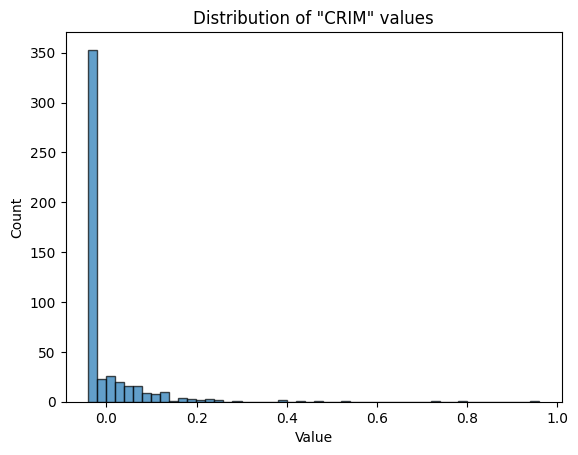

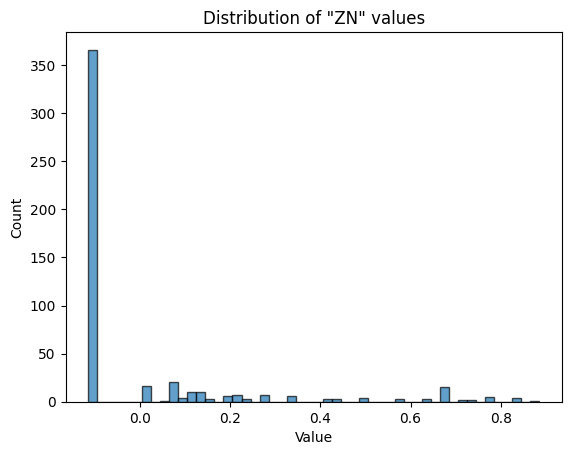

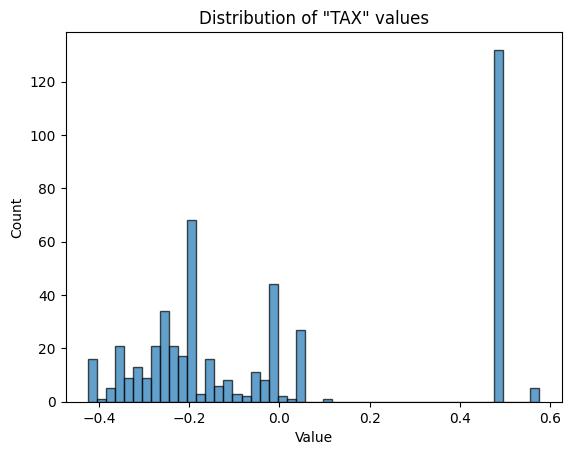

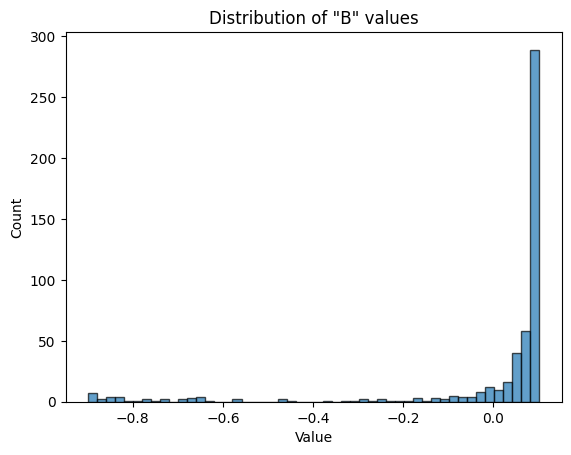

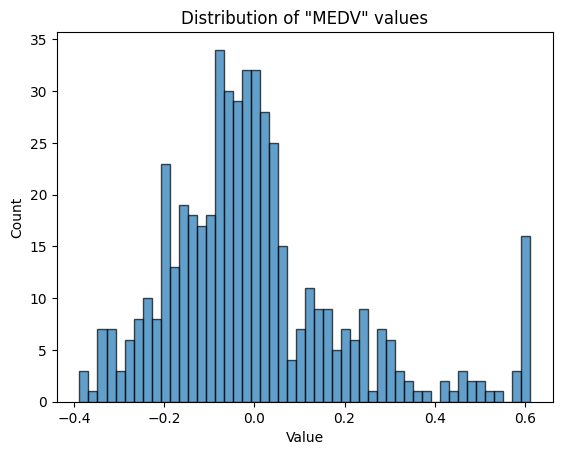

In [193]:
for col in mean_norm_df:
    plot_histogram(mean_norm_df[col])

#### 6. Logarithmic Transformation
$$
X_{log} = log_e(X) = ln(X)
$$

In [194]:
log_trn_df = pd.DataFrame()
for col_name in top_skewed_cols:
    if any(df[col_name] == 0):
        continue
    log_trn_df[col_name] = np.log(df[col_name])
    
log_trn_df.head(10)

,CRIM,TAX,B,MEDV
0,-1.554760,5.739793,5.957468,2.803360
1,-1.554760,5.739793,5.957468,2.803360
2,-1.554760,5.739793,5.957468,2.803360
3,-3.430523,NaN,NaN,NaN
4,NaN,5.402677,5.983684,3.589059
5,-3.511570,NaN,5.976655,3.356897
6,-2.427128,5.739793,5.980404,3.131137
7,-1.934130,5.739793,5.983684,3.299534
8,-1.554760,5.739793,5.957468,2.803360
9,-1.771722,5.739793,5.957675,2.939162


In [195]:
log_trn_df.describe()

,CRIM,TAX,B,MEDV
count,505.000000,504.000000,505.000000,505.000000
mean,-0.770903,5.934673,5.749794,3.031181
std,2.147493,0.394846,0.774200,0.408023
min,-4.703886,5.231109,-1.139434,1.609438
25%,-2.487951,5.638355,5.928312,2.815409
50%,-1.378366,5.799093,5.969398,3.049273
75%,1.302429,6.501290,5.981944,3.218876
max,4.488369,6.566672,5.983684,3.912023


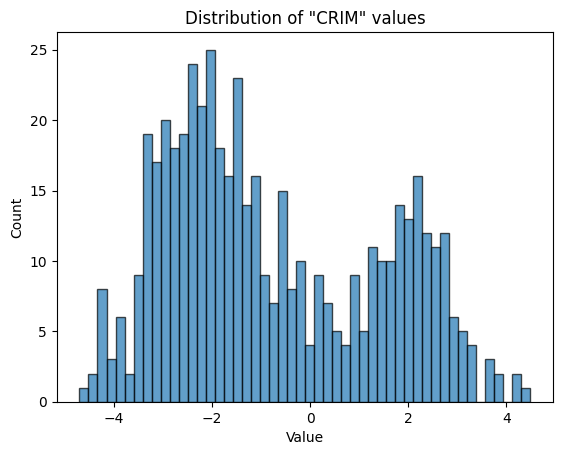

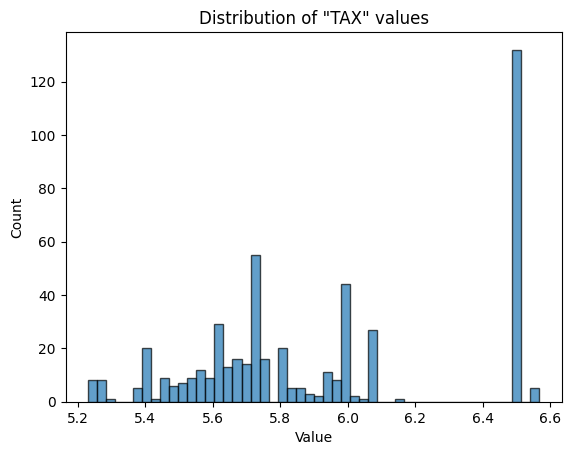

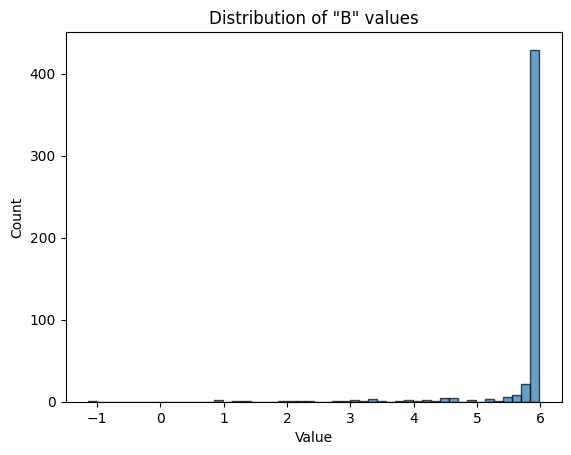

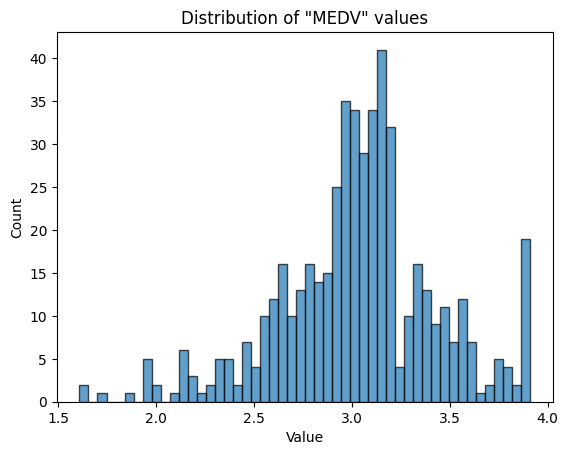

In [196]:
for col in log_trn_df:
    plot_histogram(log_trn_df[col])

#### 7. Exponential Transformation
$$
X_{exp} = exp(X) = e^X
$$

In [197]:
exp_trn_df = pd.DataFrame()
max_exp_value = 700.0
for col_name in top_skewed_cols:
    clipped_arr = np.clip(df[col_name], a_min=None, a_max=max_exp_value)
    exp_trn_df[col_name] = np.exp(clipped_arr)


exp_trn_df.head(10)

,CRIM,ZN,TAX,B,MEDV
0,1.235209,268337.286521,1.163011e+135,8.152213e+167,1.465072e+07
1,1.235209,268337.286521,1.163011e+135,8.152213e+167,1.465072e+07
2,1.235209,268337.286521,1.163011e+135,8.152213e+167,1.465072e+07
3,1.032900,NaN,NaN,NaN,NaN
4,NaN,1.000000,2.590449e+96,2.352230e+172,5.265750e+15
5,1.030300,1.000000,NaN,1.459289e+171,2.912404e+12
6,1.092305,268337.286521,1.163011e+135,6.410576e+171,8.817463e+09
7,1.155519,268337.286521,1.163011e+135,2.352230e+172,5.880042e+11
8,1.235209,268337.286521,1.163011e+135,8.152213e+167,1.465072e+07
9,1.185352,268337.286521,1.163011e+135,8.831187e+167,1.614975e+08


In [198]:
exp_trn_df.agg(['min', 'max', 'mean', 'median'])

,CRIM,ZN,TAX,B,MEDV
min,1.009101e+00,1.000000e+00,1.633308e+81,1.377128e+00,1.484132e+02
max,4.384022e+38,2.688117e+43,1.014232e+304,2.352230e+172,5.184706e+21
mean,8.681233e+35,5.467681e+40,1.006183e+302,6.374883e+171,1.723425e+20
median,1.286583e+00,1.000000e+00,2.075769e+143,8.441156e+169,1.457517e+09


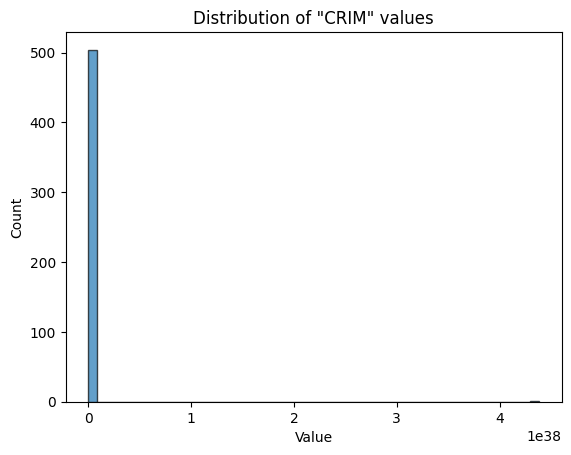

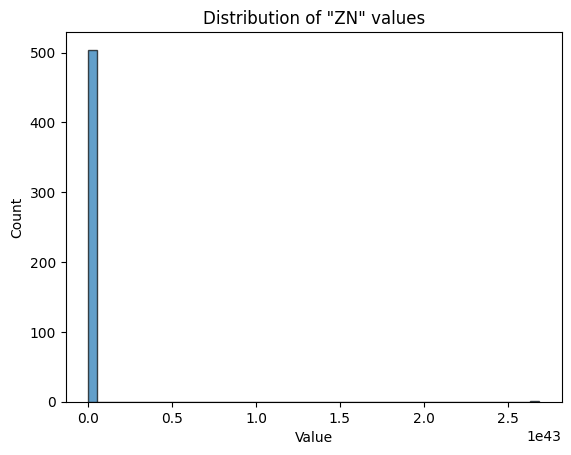

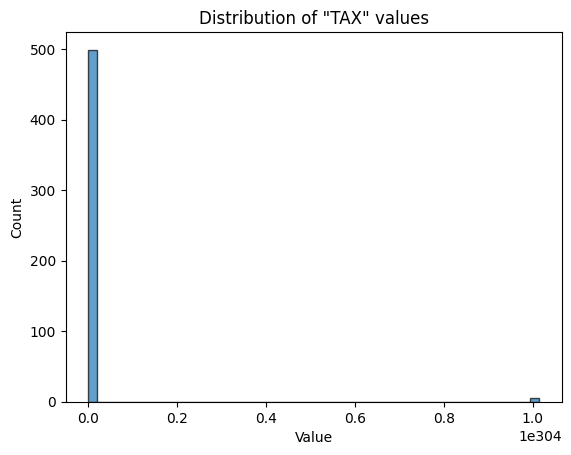

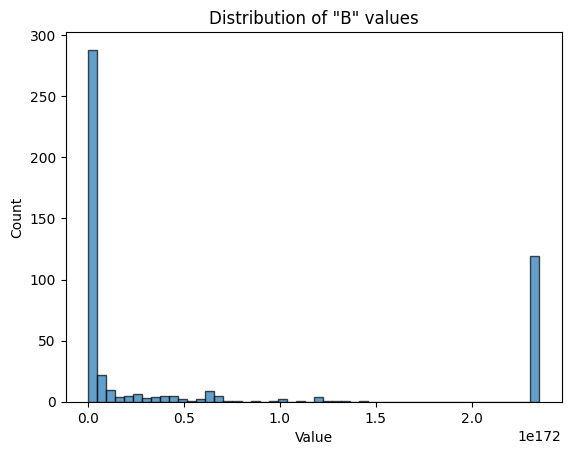

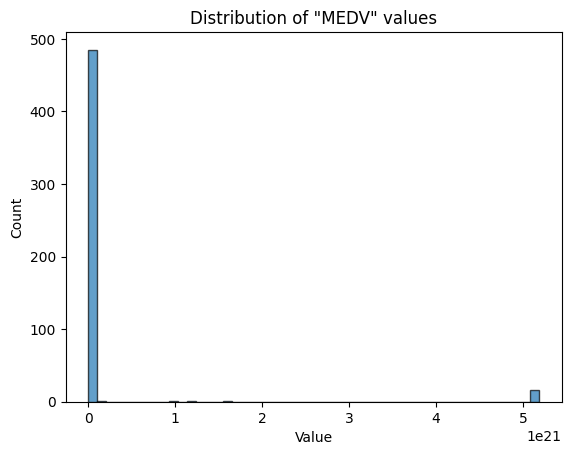

In [199]:
for col in exp_trn_df:
    plot_histogram(exp_trn_df[col])

#### 8. Power Transformation
$$
X_{pow} = X^a
$$
or more specific: $X_{pow\_sqrt} = \sqrt{X}$, $X_{pow\_3} = X^3$

In [200]:
pwr_trn_df = pd.DataFrame()
for col_name in top_skewed_cols:
    pwr_trn_df[col_name] = df[col_name]**2
    
pwr_trn_df.head(10)

,CRIM,ZN,TAX,B,MEDV
0,0.044622,156.25,96721.0,149482.7569,272.25
1,0.044622,156.25,96721.0,149482.7569,272.25
2,0.044622,156.25,96721.0,149482.7569,272.25
3,0.001048,NaN,NaN,NaN,NaN
4,NaN,0.00,49284.0,157529.6100,1310.44
5,0.000891,0.00,NaN,155330.5744,823.69
6,0.007795,156.25,96721.0,156499.3600,524.41
7,0.020895,156.25,96721.0,157529.6100,734.41
8,0.044622,156.25,96721.0,149482.7569,272.25
9,0.028914,156.25,96721.0,149544.6241,357.21


In [201]:
pwr_trn_df.describe()

,CRIM,ZN,TAX,B,MEDV
count,505.000000,505.000000,504.000000,505.000000,505.000000
mean,87.063844,674.539604,195768.656746,135578.118443,588.439782
std,513.753555,1824.608512,157523.451647,41812.203226,523.114642
min,0.000082,0.000000,34969.000000,0.102400,25.000000
25%,0.006902,0.000000,78961.000000,141015.270400,278.890000
50%,0.063499,0.000000,108900.000000,153092.212900,445.210000
75%,13.529302,156.250000,443556.000000,156982.364100,625.000000
max,7916.764166,10000.000000,505521.000000,157529.610000,2500.000000


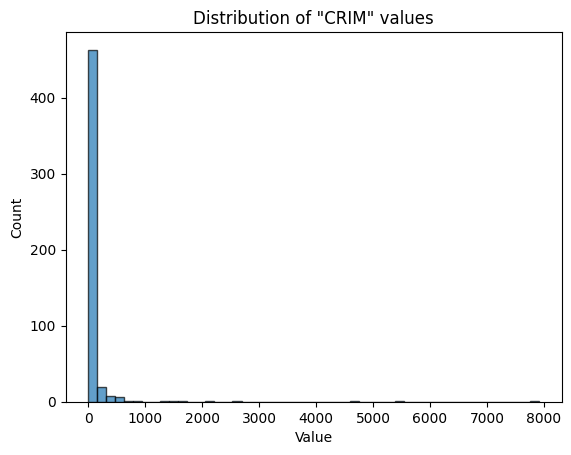

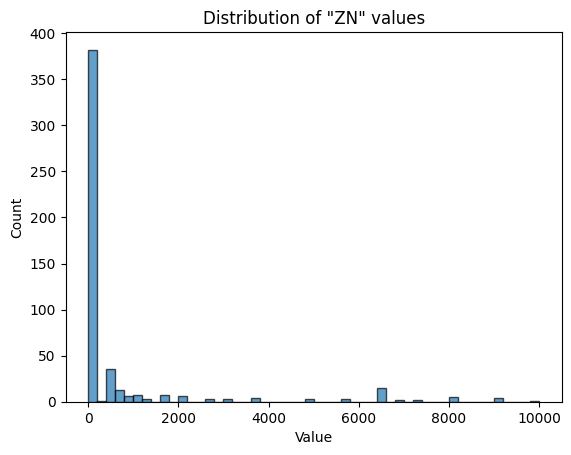

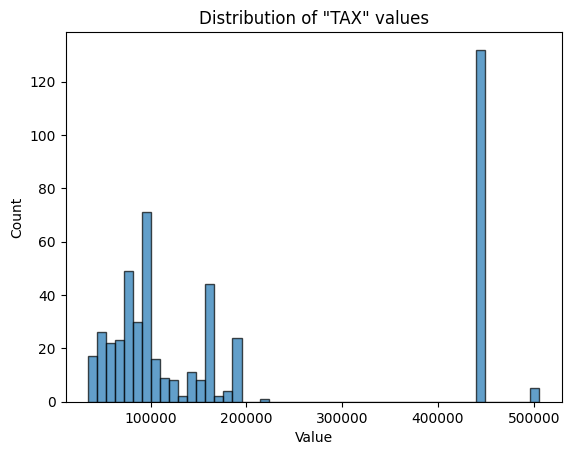

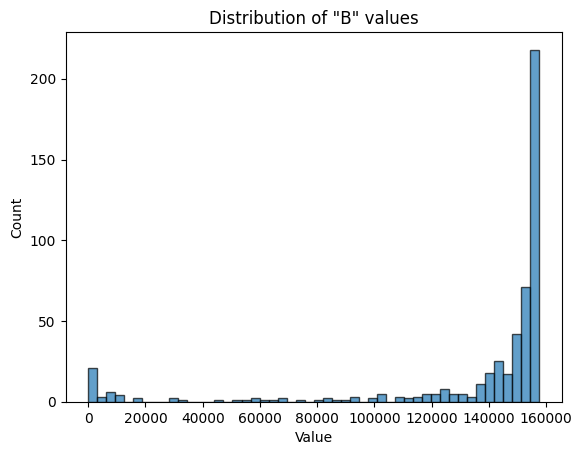

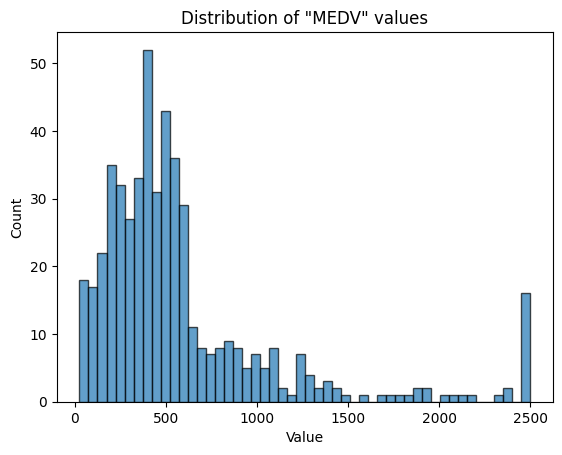

In [202]:
for col in pwr_trn_df:
    plot_histogram(pwr_trn_df[col])

 #### 8. BONUS Vector Normalization (Row-wise Normalization)
 $$
 X_{L_2} = \frac{X}{||X||_2}
 $$

In [203]:
row_wise_normalization_df = pd.DataFrame()

def row_wise_normalization(X):
    norm = np.linalg.norm(X, axis=1, keepdims=True)
    X_normalized = X / norm 
    return X_normalized

for col_name in top_skewed_cols:
    X = df.drop(col_name, axis=1)
    y = df[col_name]
    X_norm_values = row_wise_normalization(X.values)
    row_wise_normalization_df[col_name] = y.values
row_wise_normalization_df.head(10)

,CRIM,ZN,TAX,B,MEDV
0,0.21124,12.5,311.0,386.63,16.5
1,0.21124,12.5,311.0,386.63,16.5
2,0.21124,12.5,311.0,386.63,16.5
3,0.03237,NaN,NaN,NaN,NaN
4,NaN,0.0,222.0,396.90,36.2
5,0.02985,0.0,NaN,394.12,28.7
6,0.08829,12.5,311.0,395.60,22.9
7,0.14455,12.5,311.0,396.90,27.1
8,0.21124,12.5,311.0,386.63,16.5
9,0.17004,12.5,311.0,386.71,18.9


In [204]:
row_wise_normalization_df.describe()

,CRIM,ZN,TAX,B,MEDV
count,505.000000,505.000000,504.000000,505.000000,505.000000
mean,3.616803,11.499010,409.303571,356.724198,22.455644
std,8.609841,23.310693,168.212321,91.337204,9.184274
min,0.009060,0.000000,187.000000,0.320000,5.000000
25%,0.083080,0.000000,281.000000,375.520000,16.700000
50%,0.251990,0.000000,330.000000,391.270000,21.100000
75%,3.678220,12.500000,666.000000,396.210000,25.000000
max,88.976200,100.000000,711.000000,396.900000,50.000000


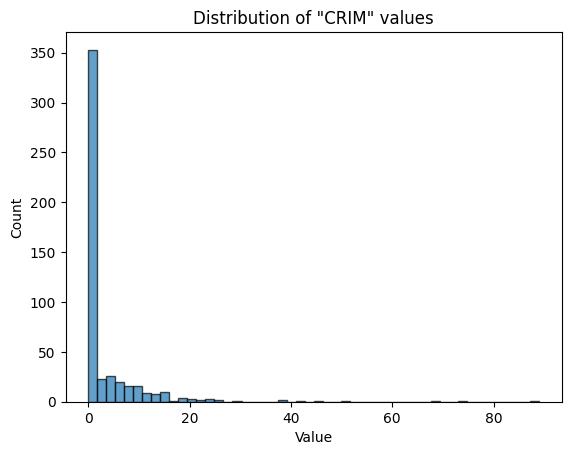

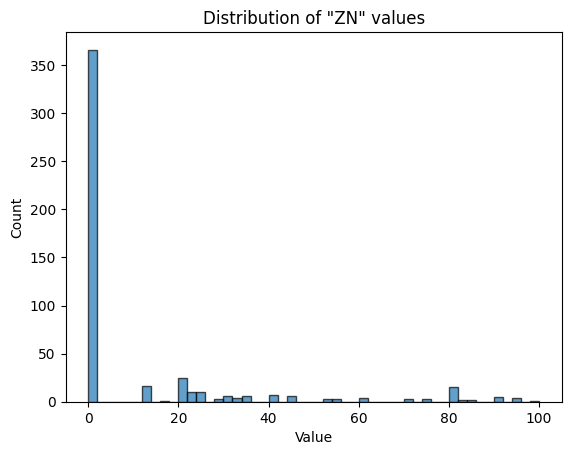

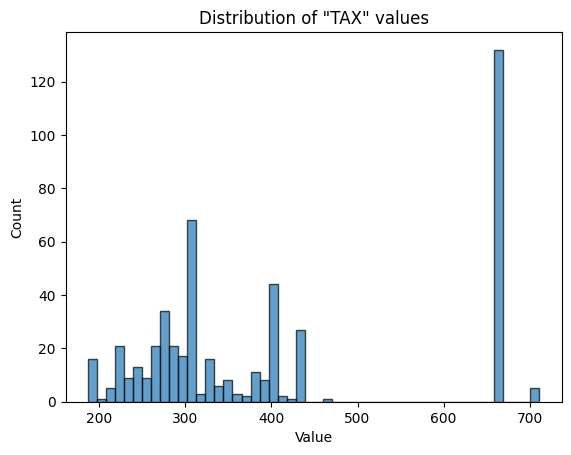

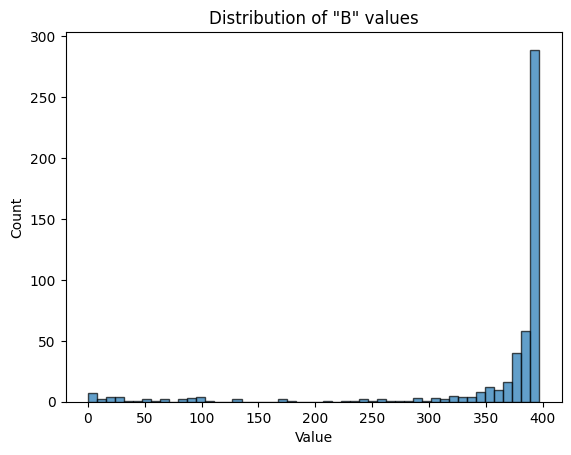

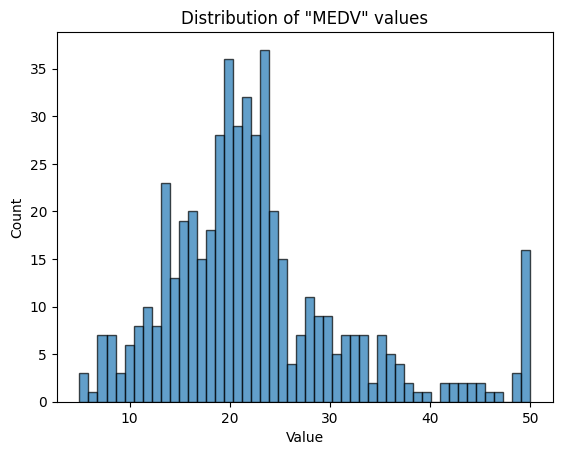

In [205]:
for col in row_wise_normalization_df:
    plot_histogram(row_wise_normalization_df[col])